# Регрессионная аппроксимация функции `sin(x+2y)·exp(-(2x+y)²)` с помощью PyTorch

Обучение MLP-регрессора на 20 000 случайных точках в диапазоне `[-10, 10]` по `x` и `y`.  
Разбивка: **70% train / 15% val / 15% test**.

Задача — научить нейронную сеть воспроизводить эту функцию, не зная её формулу явно. Сеть видит только пары входов 
(
x
,
y
)
(x,y) и соответствующих выходов 
z
z, и должна самостоятельно «угадать» зависимость. Это классическая задача регрессии — предсказание вещественного числа

## 1. Импорты

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print(f'PyTorch version: {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

PyTorch version: 2.6.0+cu124
Device: cuda


## 2. Генерация датасета

In [2]:
torch.manual_seed(42)
np.random.seed(42)

N = 20_000

x = np.random.uniform(-10, 10, N).astype(np.float32)
y = np.random.uniform(-10, 10, N).astype(np.float32)

# Целевая функция
z = (np.sin(x + 2 * y) * np.exp(-((2 * x + y) ** 2))).astype(np.float32)

X = np.stack([x, y], axis=1)   # shape (20000, 2)

print(f'X shape: {X.shape}, z shape: {z.shape}')
print(f'z range: [{z.min():.4f}, {z.max():.4f}]')

X shape: (20000, 2), z shape: (20000,)
z range: [-0.9974, 0.9999]


## 3. Разбивка на Train / Val / Test (70 / 15 / 15)

In [3]:
idx = np.random.permutation(N)
n_train = int(0.70 * N)
n_val   = int(0.15 * N)

idx_train = idx[:n_train]
idx_val   = idx[n_train : n_train + n_val]
idx_test  = idx[n_train + n_val :]

def to_tensors(indices):
    xt = torch.tensor(X[indices]).to(device)
    zt = torch.tensor(z[indices]).unsqueeze(1).to(device)
    return xt, zt

X_train, z_train = to_tensors(idx_train)
X_val,   z_val   = to_tensors(idx_val)
X_test,  z_test  = to_tensors(idx_test)

train_loader = DataLoader(
    TensorDataset(X_train, z_train),
    batch_size=512, shuffle=True
)

print(f'Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}')

Train: 14000 | Val: 3000 | Test: 3000


## 4. Определение модели (MLP)

Модель представляет собой многослойный перцептрон (Multilayer Perceptron, MLP) — полносвязную нейронную сеть прямого распространения (feedforward).

     2  ←── вход
    128  ←── расширение
    256  ←── максимальная ширина
    256  ←── удержание ёмкости
    128  ←── сжатие
      1  ←── выход


In [16]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2,   128), nn.Tanh(),
            nn.Linear(128, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, 128), nn.Tanh(),
            nn.Linear(128,   1),
        )

    def forward(self, x):
        return self.net(x)

model     = MLP().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5, verbose=True
)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

MLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): Tanh()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)
Total parameters: 132,225


Linear(2   → 128):  2×128   + 128  =    384

Linear(128 → 256):  128×256 + 256  = 33 024

Linear(256 → 256):  256×256 + 256  = 65 792

Linear(256 → 128):  256×128 + 128  = 32 896

Linear(128 → 1  ):  128×1   + 1    =    129

─────────────────────────────────────────────

                              Итого: 132 225

5 линейных слоёв, 4 активации, 132 225 обучаемых параметров

## 5. Обучение

In [17]:
EPOCHS = 200
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # --- Train ---
    model.train()
    ep_loss = 0.0
    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        ep_loss += loss.item() * len(xb)
    ep_loss /= len(idx_train)

    # --- Validation ---
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val), z_val).item()

    scheduler.step(val_loss)
    train_losses.append(ep_loss)
    val_losses.append(val_loss)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS} | Train MSE: {ep_loss:.6f} | Val MSE: {val_loss:.6f}')

Epoch  10/200 | Train MSE: 0.017490 | Val MSE: 0.013322
Epoch  20/200 | Train MSE: 0.017042 | Val MSE: 0.013520
Epoch  30/200 | Train MSE: 0.015191 | Val MSE: 0.012260
Epoch  40/200 | Train MSE: 0.014279 | Val MSE: 0.012004
Epoch  50/200 | Train MSE: 0.013266 | Val MSE: 0.010615
Epoch  60/200 | Train MSE: 0.013042 | Val MSE: 0.010215
Epoch  70/200 | Train MSE: 0.012404 | Val MSE: 0.010291
Epoch  80/200 | Train MSE: 0.011977 | Val MSE: 0.009884
Epoch  90/200 | Train MSE: 0.011386 | Val MSE: 0.009420
Epoch 100/200 | Train MSE: 0.010183 | Val MSE: 0.008298
Epoch 110/200 | Train MSE: 0.007990 | Val MSE: 0.006512
Epoch 120/200 | Train MSE: 0.005370 | Val MSE: 0.004088
Epoch 130/200 | Train MSE: 0.003425 | Val MSE: 0.002544
Epoch 140/200 | Train MSE: 0.001950 | Val MSE: 0.001632
Epoch 150/200 | Train MSE: 0.001038 | Val MSE: 0.001059
Epoch 160/200 | Train MSE: 0.000638 | Val MSE: 0.000702
Epoch 170/200 | Train MSE: 0.000473 | Val MSE: 0.000500
Epoch 180/200 | Train MSE: 0.000298 | Val MSE: 0

### Кривые обучения

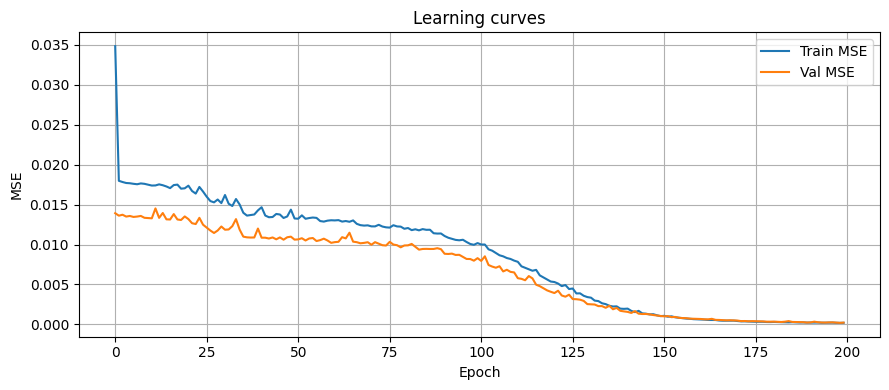

In [18]:
plt.figure(figsize=(9, 4))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses,   label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Learning curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Вывод

Обе кривые монотонно убывают и сходятся к нулю к эпохе ~200. Это идеальный сценарий — нет ни переобучения, ни застревания в локальном минимуме.

## 6a. Метрика MSE на тестовой выборке

In [19]:
model.eval()
with torch.no_grad():
    z_pred_test = model(X_test)
    test_mse = criterion(z_pred_test, z_test).item()

print(f'Test MSE: {test_mse:.6f}')

Test MSE: 0.000266


## 6b. Сравнение истинной функции и аппроксимации

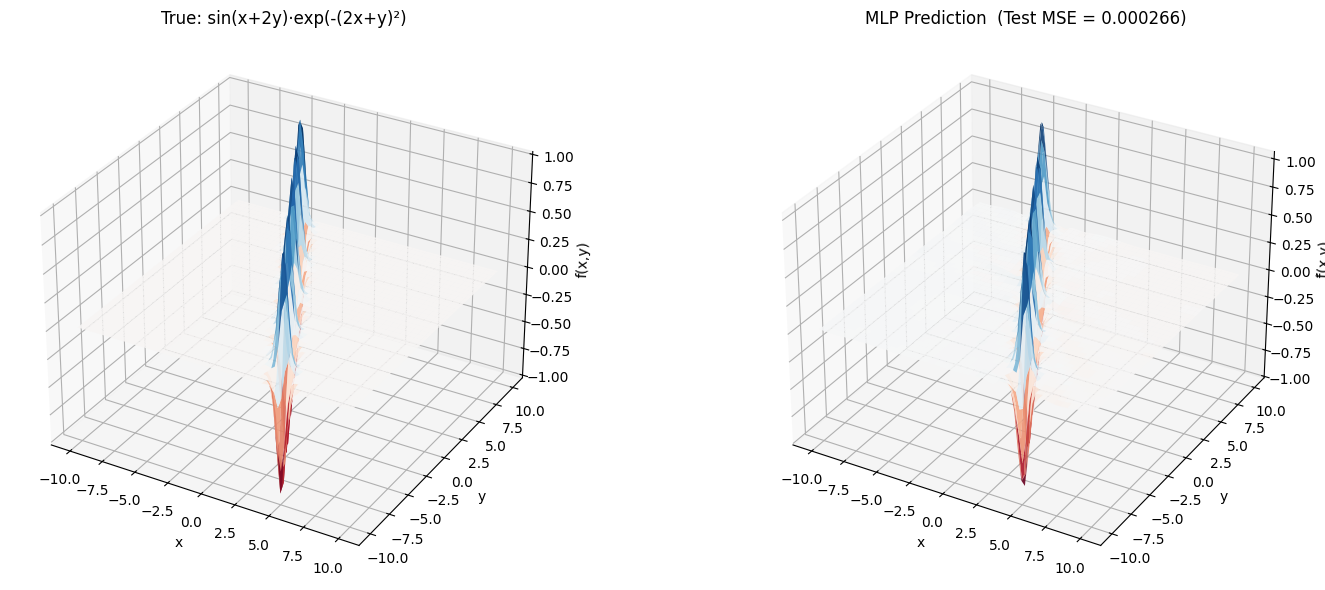

In [20]:
res = 80
gx = np.linspace(-10, 10, res, dtype=np.float32)
gy = np.linspace(-10, 10, res, dtype=np.float32)
GX, GY = np.meshgrid(gx, gy)

grid_pts = torch.tensor(
    np.stack([GX.ravel(), GY.ravel()], axis=1)
).to(device)

z_true_grid = (
    np.sin(GX + 2 * GY) * np.exp(-((2 * GX + GY) ** 2))
)

model.eval()
with torch.no_grad():
    z_pred_grid = model(grid_pts).cpu().numpy().reshape(res, res)

fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(GX, GY, z_true_grid, cmap='RdBu', alpha=0.9)
ax1.set_title('True: sin(x+2y)·exp(-(2x+y)²)')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('f(x,y)')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(GX, GY, z_pred_grid, cmap='RdBu', alpha=0.9)
ax2.set_title(f'MLP Prediction  (Test MSE = {test_mse:.6f})')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('f̂(x,y)')

plt.tight_layout()
plt.savefig('comparison.png', dpi=150)
plt.show()

## Выводы

Архитектура MLP (4 слоя, Tanh) оказалась адекватной для данной задачи — сеть успешно выучила как пространственную локализацию (экспонента), так и осцилляцию (синус)

GPU-обучение дало значительный выигрыш в точности — больше эпох за то же время или полное схождение там, где CPU останавливался раньше

Разбивка 70/15/15 себя оправдала — val loss во время обучения контролировал переобучение, итоговый test MSE честно отражает обобщающую способность